Preprocessing

Goal: Convert the continuous EEG recording for Subject AO1 into individual left and right hand motor imagery trials. This is done by identifying the motor imagery events, creating epochs around each event, and then applying a band-pass filter. 

I am focusing on binary classification between motor imagery for the left and right hands. 

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt

file_path = "/Users/vaneeza/EEG_BCI_Project/data/BCICIV_2a_gdf/A01T.gdf"
raw = mne.io.read_raw_gdf(file_path, preload=True)
print (raw)

# event identification
events, event_id = mne.events_from_annotations(raw, event_id = "auto")
print (event_id)

left_hand_code = event_id["769"]
right_hand_code = event_id["770"]
print("Left Hand Code:", left_hand_code)
print("Right Hand Code:", right_hand_code)

motor_events = {
    "left_hand": left_hand_code,
    "right_hand": right_hand_code
}
print(motor_events)

# Each epoch will begin 0.5 seconds before the cue and end 4 seconds after.
# This marks each trial of motor imagery. The 0.5 seconds prior to the cue is a baseline.
epochs = mne.Epochs(
    raw, events, event_id=motor_events, 
    tmin = -0.5, tmax =4.0, baseline = (-0.5,0), preload = True)
print(epochs)

Extracting GDF parameters from /Users/vaneeza/EEG_BCI_Project/data/BCICIV_2a_gdf/A01T.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>
Used Annotations descriptions: [np.str_('1023'), np.str_('1072'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('771'), np.str_('772')]
{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
Left Hand Code: 7
Right Hand Code: 8
{'left_hand': 7, 'right_hand': 8}
Not setting metadata
144 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1126 original time points ...
0 bad epochs dropped
<Epochs | 144 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~30.9 MiB, data loaded,
 'left_hand': 72
 'right_hand': 72>


In [3]:
print ("Total Number of Epochs:", len(epochs))
print ("Left Hand Epochs:", len(epochs["left_hand"]))
print ("Right Hand Epochs:", len(epochs["right_hand"]))

Total Number of Epochs: 144
Left Hand Epochs: 72
Right Hand Epochs: 72


In [8]:
print("Original number of channels:", len(epochs.ch_names))
print(epochs.ch_names)

# Remove the three eye-movement channels - not needed



epochsbeforefilter = epochs.copy ()
# Copy of the original epochs to compare later

# Filter the data to only include frequencies between 8 and 30 Hz.
epochs.filter( l_freq = 8, h_freq = 30)
# 8-30 Hz includes mu and beta rhythms, commonly associated with motor imagery and movement in the sensorimotor cortex

# Crop epochs to focus the analysis on the main window of motor imagery.
epochs.crop(tmin = 0.5, tmax = 3.5)
print(epochs)

# Inspect the EEG data points after filtering
data = epochs.get_data()
print ("EEG Data Shape - Final:", data.shape)

trialnumber = data.shape[0]
channelnumber = data.shape [1]
timepointsnumber = data.shape [2]
print("Trials:", trialnumber)
print("Channels:", channelnumber)
print("Time Points/Trial:", timepointsnumber)

Original number of channels: 22
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16']
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method


- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

<Epochs | 144 events (all good), 0.5 – 3.5 s (baseline -0.5 – 0 s (baseline period was cropped after baseline correction)), ~18.2 MiB, data loaded,
 'left_hand': 72
 'right_hand': 72>
EEG Data Shape - Final: (144, 22, 751)
Trials: 144
Channels: 22
Time Points/Trial: 751


Each of the 144 trials has recordings across 22 EEG channels

Using matplotlib as 2D backend.


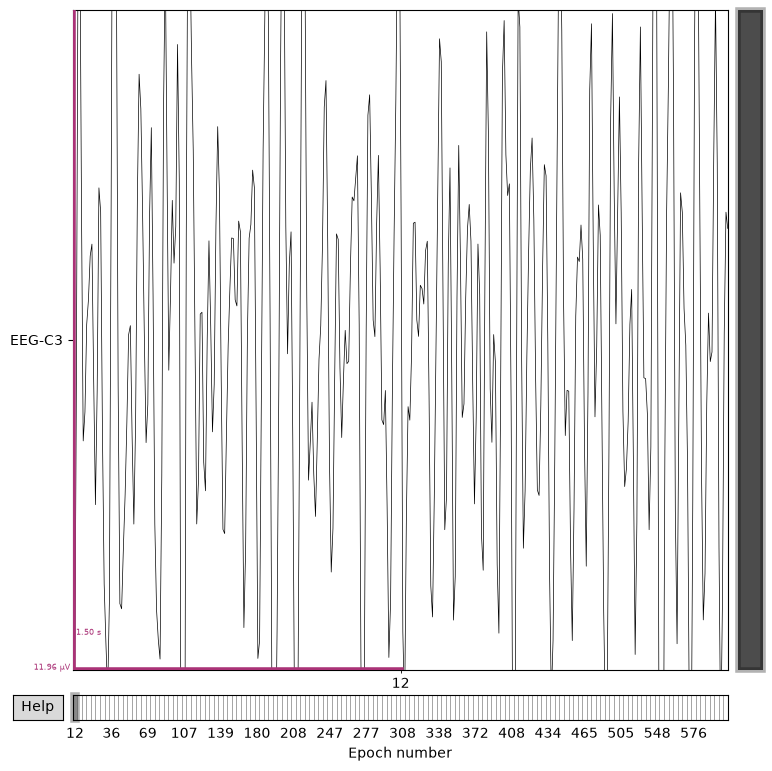

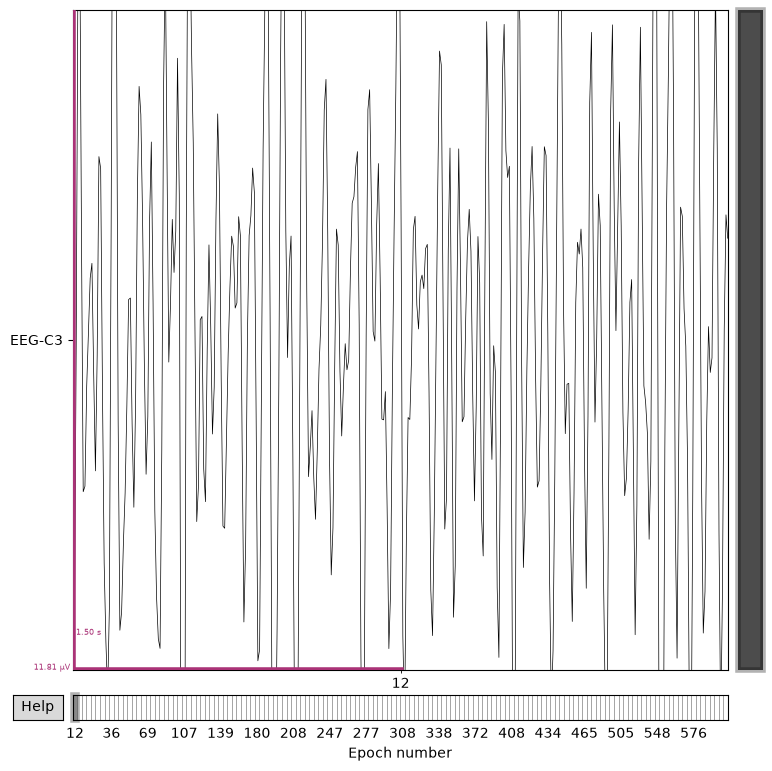

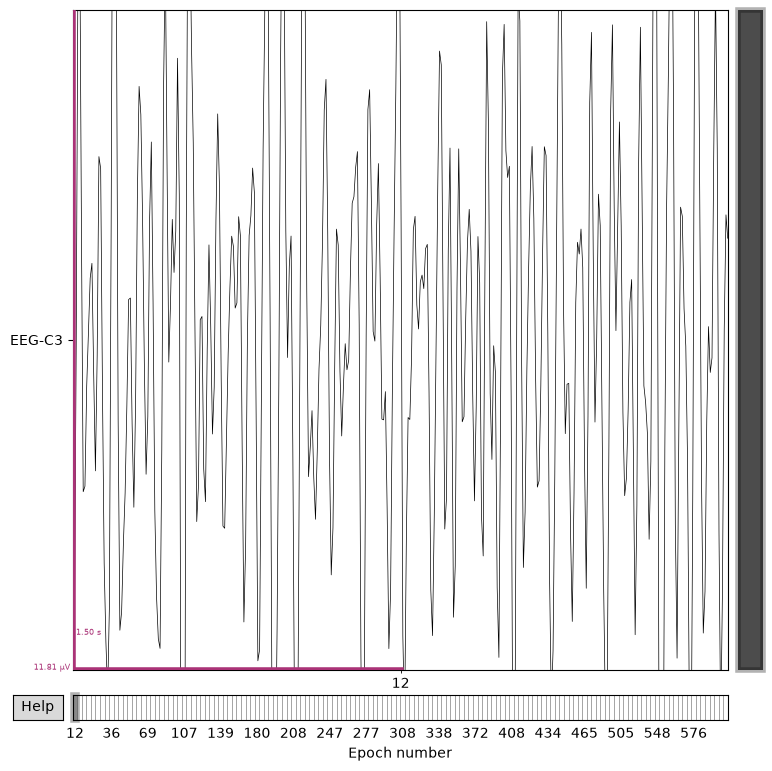

In [9]:
# Comparison of before and after filtering
epochsbeforefilter.copy().pick(["EEG-C3"]).plot(
n_epochs = 1,
n_channels = 1,
scalings = "auto"
)

epochs.copy().pick(["EEG-C3"]).plot(
n_epochs = 1,
n_channels = 1,
scalings = "auto" 
)